# Phase 3 — Pure Boundary Transition Classifier

**Goal:** raise precision for label 1 by making Phase 3 a *boundary-only* signal that is statistically orthogonal to Phase 1 (global) and Phase 2 (envelope). At inference, the three phases are cascaded so a candidate must pass all three; independent errors compound and false positives drop.

Key changes vs. the previous attempt in this notebook:
1. P3 features are **only** what happens at the cut (last K=12s of A vs first K=12s of B). No `tempo_diff`, no `energy_diff`, no `siamese_vibe_dist` inside the P3 model.
2. P1 and P2 are computed (frozen) and used for: (a) **hard-case sample weighting** during P3 training, (b) **cascade evaluation** at inference — never as P3 input features.
3. Loudness is converted from raw RMS to dB so `is_gain_shock` is meaningful.
4. Train/val split is **grouped by playlist** to prevent leakage.
5. XGBoost is **isotonic-calibrated**, threshold tuned to maximize `precision_1` subject to `recall_1 ≥ 0.75`.

In [25]:
import os, json, warnings
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
DATA_DIR  = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

EPS = 1e-6
K_WINDOW = 12              # boundary window in 1-second frames
RECALL_FLOOR = 0.75        # minimum recall_1 we accept when picking tau3
RANDOM_STATE = 42

print('Project root :', PROJECT_ROOT)
print('Data dir     :', DATA_DIR)
print('Model dir    :', MODEL_DIR)

Project root : C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system
Data dir     : C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed
Model dir    : C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\models


## 1. Load labeled pairs and per-track features
We use `phase2_siamese_training_pairs.csv` because it carries both the raw matrix paths (variable-length) and the fixed (128,30) matrix paths, and is the subset that has downloaded audio.

In [26]:
pairs = pd.read_csv(DATA_DIR / 'phase2_siamese_training_pairs.csv')
clean = pd.read_csv(DATA_DIR / 'clean_dataset.csv')

AUDIO_FEATS = ['Danceability','Energy','Loudness','Speechiness','Acousticness',
               'Instrumentalness','Liveness','Valence','Tempo','Mode','Key']

meta = clean[['track_id'] + AUDIO_FEATS].drop_duplicates('track_id')

src = meta.add_prefix('source_').rename(columns={'source_track_id':'source_track_id'})
tgt = meta.add_prefix('target_').rename(columns={'target_track_id':'target_track_id'})
pairs = pairs.merge(src, on='source_track_id', how='left')
pairs = pairs.merge(tgt, on='target_track_id', how='left')

print('Pairs:', len(pairs))
print('Label distribution:')
print(pairs['label'].value_counts())
print('Unique playlists (source_pid):', pairs['source_pid'].nunique())

Pairs: 3672
Label distribution:
label
0    2448
1    1224
Name: count, dtype: int64
Unique playlists (source_pid): 25


## 2. Frozen Phase 1 score (NOT a P3 input — used for hard-case mining + cascade)

In [27]:
p1_model = joblib.load(MODEL_DIR / 'phase1_xgboost_model.pkl')

# The Phase 1 feature_matrix.csv column order:
P1_DIFF_ORDER = ['danceability','energy','loudness','speechiness','acousticness',
                 'instrumentalness','liveness','valence','tempo','mode','key_fifths']

def key_to_fifths(k):
    # Spotify Key in [0..11] (-1 unknown). Map to circle-of-fifths index.
    table = {0:0, 7:1, 2:2, 9:3, 4:4, 11:5, 6:6, 1:7, 8:8, 3:9, 10:10, 5:11}
    return table.get(int(k), 0) if pd.notna(k) and k != -1 else 0

def fifths_diff(a, b):
    fa, fb = key_to_fifths(a), key_to_fifths(b)
    d = abs(fa - fb)
    return min(d, 12 - d)

def build_p1_diffs(df):
    out = pd.DataFrame()
    out['diff_danceability']    = (df['source_Danceability']    - df['target_Danceability']).abs()
    out['diff_energy']          = (df['source_Energy']          - df['target_Energy']).abs()
    out['diff_loudness']        = (df['source_Loudness']        - df['target_Loudness']).abs()
    out['diff_speechiness']     = (df['source_Speechiness']     - df['target_Speechiness']).abs()
    out['diff_acousticness']    = (df['source_Acousticness']    - df['target_Acousticness']).abs()
    out['diff_instrumentalness']= (df['source_Instrumentalness']- df['target_Instrumentalness']).abs()
    out['diff_liveness']        = (df['source_Liveness']        - df['target_Liveness']).abs()
    out['diff_valence']         = (df['source_Valence']         - df['target_Valence']).abs()
    out['diff_tempo']           = (df['source_Tempo']           - df['target_Tempo']).abs()
    out['diff_mode']            = (df['source_Mode']            - df['target_Mode']).abs()
    out['diff_key_fifths']      = [fifths_diff(a,b) for a,b in zip(df['source_Key'], df['target_Key'])]
    return out.fillna(0.0)

X_p1 = build_p1_diffs(pairs)
pairs['p1_score'] = p1_model.predict_proba(X_p1.values)[:, 1]
print('P1 score stats:'); print(pairs['p1_score'].describe())

P1 score stats:
count    3672.000000
mean        0.427304
std         0.359035
min         0.000132
25%         0.011577
50%         0.488087
75%         0.775567
max         0.991318
Name: p1_score, dtype: float64


## 3. Frozen Phase 2 score (Siamese euclidean distance → similarity)

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

INPUT_SHAPE = (128, 30)
EMBEDDING_DIM = 128

def build_encoder():
    inp = layers.Input(shape=INPUT_SHAPE)
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(EMBEDDING_DIM, activation='relu')(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    return Model(inp, x, name='phase2_encoder')

encoder = build_encoder()
src_in = layers.Input(shape=INPUT_SHAPE); tgt_in = layers.Input(shape=INPUT_SHAPE)
dist = layers.Lambda(
    lambda t: tf.sqrt(tf.reduce_sum(tf.square(t[0]-t[1]), axis=1, keepdims=True))
)([encoder(src_in), encoder(tgt_in)])
siamese = Model([src_in, tgt_in], dist)
siamese.load_weights(MODEL_DIR / 'phase2_siamese_model.keras')
print('Siamese weights loaded.')

# Embed all unique fixed matrices once, then compute pair distances in one shot.
uniq_paths = pd.unique(pd.concat([pairs['source_fixed_matrix_path'],
                                  pairs['target_fixed_matrix_path']]))
print('Unique fixed matrices to embed:', len(uniq_paths))

BATCH = 64
embs = {}
buf_paths = []; buf = []
for p in uniq_paths:
    buf.append(np.load(p)); buf_paths.append(p)
    if len(buf) == BATCH:
        e = encoder.predict(np.stack(buf), verbose=0)
        for pp, ee in zip(buf_paths, e): embs[pp] = ee
        buf, buf_paths = [], []
if buf:
    e = encoder.predict(np.stack(buf), verbose=0)
    for pp, ee in zip(buf_paths, e): embs[pp] = ee

src_emb = np.stack([embs[p] for p in pairs['source_fixed_matrix_path']])
tgt_emb = np.stack([embs[p] for p in pairs['target_fixed_matrix_path']])
p2_dist = np.linalg.norm(src_emb - tgt_emb, axis=1)
# Map to similarity in [0,1]: smaller distance => higher similarity. Embeddings are L2-normalized so dist in [0,2].
pairs['p2_dist'] = p2_dist
pairs['p2_score'] = 1.0 - np.clip(p2_dist / 2.0, 0, 1)
print('P2 distance stats:'); print(pairs['p2_dist'].describe())
print('P2 similarity stats:'); print(pairs['p2_score'].describe())

Siamese weights loaded.
Unique fixed matrices to embed: 1338
P2 distance stats:
count    3672.000000
mean        0.899422
std         0.296166
min         0.000000
25%         0.642360
50%         0.964697
75%         1.175057
max         1.340531
Name: p2_dist, dtype: float64
P2 similarity stats:
count    3672.000000
mean        0.550289
std         0.148083
min         0.329735
25%         0.412472
50%         0.517651
75%         0.678820
max         1.000000
Name: p2_score, dtype: float64


## 4. Pure boundary feature extraction (the only inputs P3 will see)

Matrix column layout (from Phase 2 extraction): `[RMS, centroid, bandwidth, rolloff, ZCR, MFCC1..13, chroma1..12]`. We use only what's local to the cut.

In [29]:
RMS_COL    = 0
CENT_COL   = 1
MFCC_COLS  = slice(5, 18)
CHROMA_COLS= slice(18, 30)

def db(rms):
    return 20.0 * np.log10(np.maximum(rms, EPS))

def slope(x):
    if len(x) < 2: return 0.0
    return float(np.polyfit(np.arange(len(x)), x, 1)[0])

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < EPS or nb < EPS: return 0.0
    return float(np.dot(a, b) / (na * nb))

def boundary_features(mat_a, mat_b, K=K_WINDOW):
    """Pure boundary stats. mat_a, mat_b are (T, 30) raw matrices."""
    Ka = min(K, mat_a.shape[0]); Kb = min(K, mat_b.shape[0])
    tail = mat_a[-Ka:]
    head = mat_b[:Kb]

    # Loudness (RMS -> dB)
    tail_db = db(tail[:, RMS_COL])
    head_db = db(head[:, RMS_COL])
    end_db   = float(np.mean(tail_db[-3:]))
    start_db = float(np.mean(head_db[:3]))
    loudness_gap        = start_db - end_db
    abs_loudness_gap    = abs(loudness_gap)
    is_gain_shock       = float(loudness_gap > 6.0)

    # Slopes near the cut (last/first 4 frames)
    tail_slope = slope(tail_db[-4:])
    head_slope = slope(head_db[:4])
    slope_clash = -tail_slope * head_slope  # fade-into-rise: tail_slope<0 & head_slope>0 -> positive (bad)
    attack_strength_b = float(np.max(head_db[:3]) - np.min(head_db[:3]))
    decay_completion_a = float(np.max(tail_db) - end_db) / (abs(np.max(tail_db)) + EPS)

    # Timbre (mean MFCCs over window)
    tail_mfcc = tail[:, MFCC_COLS].mean(axis=0)
    head_mfcc = head[:, MFCC_COLS].mean(axis=0)
    timbre_l2  = float(np.linalg.norm(tail_mfcc - head_mfcc))
    timbre_cos = 1.0 - cosine(tail_mfcc, head_mfcc)

    # Brightness (spectral centroid, log-scaled)
    tail_b = float(np.log1p(np.mean(tail[:, CENT_COL])))
    head_b = float(np.log1p(np.mean(head[:, CENT_COL])))
    brightness_gap = abs(head_b - tail_b)

    # Texture stability (variance of MFCCs across window, summed)
    tail_var = float(tail[:, MFCC_COLS].var(axis=0).sum())
    head_var = float(head[:, MFCC_COLS].var(axis=0).sum())
    texture_var_diff = abs(head_var - tail_var)

    # Pitch / chroma continuity
    tail_chr = tail[:, CHROMA_COLS].mean(axis=0)
    head_chr = head[:, CHROMA_COLS].mean(axis=0)
    chroma_continuity = cosine(tail_chr, head_chr)  # 1 = same key center

    # Soft-splice indicator: both ends near silence
    boundary_silence_match = float((end_db < -25) and (start_db < -25))

    return {
        'loudness_gap': loudness_gap,
        'abs_loudness_gap': abs_loudness_gap,
        'is_gain_shock': is_gain_shock,
        'tail_slope': tail_slope,
        'head_slope': head_slope,
        'slope_clash': slope_clash,
        'attack_strength_b': attack_strength_b,
        'decay_completion_a': decay_completion_a,
        'timbre_l2': timbre_l2,
        'timbre_cos': timbre_cos,
        'brightness_gap': brightness_gap,
        'texture_var_diff': texture_var_diff,
        'chroma_continuity': chroma_continuity,
        'boundary_silence_match': boundary_silence_match,
    }

# Cache per-track tail/head info? Boundary features depend on the *pair*, so we just iterate.
# But we can cache loaded raw matrices to avoid duplicate disk reads.
raw_cache = {}
def load_raw(p):
    if p not in raw_cache: raw_cache[p] = np.load(p)
    return raw_cache[p]

rows = []
fail = 0
for i, r in pairs.iterrows():
    try:
        ma = load_raw(r['source_matrix_path'])
        mb = load_raw(r['target_matrix_path'])
        rows.append(boundary_features(ma, mb))
    except Exception as e:
        rows.append({k: np.nan for k in [
            'loudness_gap','abs_loudness_gap','is_gain_shock','tail_slope','head_slope',
            'slope_clash','attack_strength_b','decay_completion_a','timbre_l2','timbre_cos',
            'brightness_gap','texture_var_diff','chroma_continuity','boundary_silence_match']})
        fail += 1
    if i and i % 500 == 0: print(f'  ...{i}/{len(pairs)}')
raw_cache.clear()
boundary = pd.DataFrame(rows, index=pairs.index)
print(f'Boundary feature extraction done. failures={fail}')
boundary.head()

  ...500/3672
  ...1000/3672
  ...1500/3672
  ...2000/3672
  ...2500/3672
  ...3000/3672
  ...3500/3672
Boundary feature extraction done. failures=0


,loudness_gap,abs_loudness_gap,is_gain_shock,tail_slope,head_slope,slope_clash,attack_strength_b,decay_completion_a,timbre_l2,timbre_cos,brightness_gap,texture_var_diff,chroma_continuity,boundary_silence_match
0,23.662506,23.662506,1.0,-18.171857,-0.979472,-17.798828,2.753836,5.542586,224.157700,0.509690,0.968245,47356.820190,0.858534,1.0
1,29.545044,29.545044,1.0,-16.946205,8.885132,150.569270,24.473213,2.417312,93.167274,0.047122,0.153636,7842.557617,0.324444,1.0
2,7.435531,7.435531,1.0,-3.487755,0.967303,3.373717,3.487676,0.739581,90.051308,0.097490,0.627060,3323.127441,0.924132,0.0
3,-4.364429,4.364429,0.0,-17.555911,14.782803,259.525567,49.805748,1.951715,308.426300,1.131051,1.231999,18125.279297,0.710799,1.0
4,67.853793,67.853793,1.0,-19.020059,1.067749,20.308656,4.531157,3.204588,181.367035,0.297628,2.214735,19603.052856,0.941304,0.0


## 5. Assemble dataset, hard-case sample weights, playlist-grouped split

In [30]:
BOUNDARY_FEATURES = list(boundary.columns)
df = pd.concat([
    pairs[['source_track_id','target_track_id','source_pid','label','p1_score','p2_score']].reset_index(drop=True),
    boundary.reset_index(drop=True)
], axis=1).dropna(subset=BOUNDARY_FEATURES).reset_index(drop=True)
print('Final dataset:', df.shape, 'label dist:', df['label'].value_counts().to_dict())

# Hard-case definition
tau1 = float(np.quantile(df['p1_score'], 0.6))   # "P1 confident-positive" cutoff
tau2 = float(np.quantile(df['p2_score'], 0.6))   # same for P2
fp_mask = (df['p1_score'] >= tau1) & (df['p2_score'] >= tau2) & (df['label'] == 0)  # P1+P2 say smooth, truth says jarring
fn_mask = ((df['p1_score'] < tau1) | (df['p2_score'] < tau2)) & (df['label'] == 1)   # P1+P2 doubt, truth says smooth
weights = np.ones(len(df))
weights[fp_mask.values] = 3.0
weights[fn_mask.values] = 2.0
df['sample_weight'] = weights
print(f'tau1={tau1:.3f}, tau2={tau2:.3f}, hard_FP={int(fp_mask.sum())}, hard_FN={int(fn_mask.sum())}')

# Playlist-grouped split
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, va_idx = next(gss.split(df, df['label'], groups=df['source_pid']))
df_tr = df.iloc[tr_idx].reset_index(drop=True)
df_va = df.iloc[va_idx].reset_index(drop=True)
print('Train:', len(df_tr), 'val:', len(df_va))
print('Train pos rate:', df_tr['label'].mean().round(3), 'Val pos rate:', df_va['label'].mean().round(3))

Final dataset: (3672, 20) label dist: {0: 2448, 1: 1224}
tau1=0.652, tau2=0.588, hard_FP=213, hard_FN=280
Train: 3000 val: 672
Train pos rate: 0.333 Val pos rate: 0.333


## 6. Train calibrated XGBoost on boundary-only features

scale_pos_weight = 2.0
Validation ROC-AUC  uncal=0.7214  cal=0.6715
Validation PR-AUC   uncal=0.4673  cal=0.4299


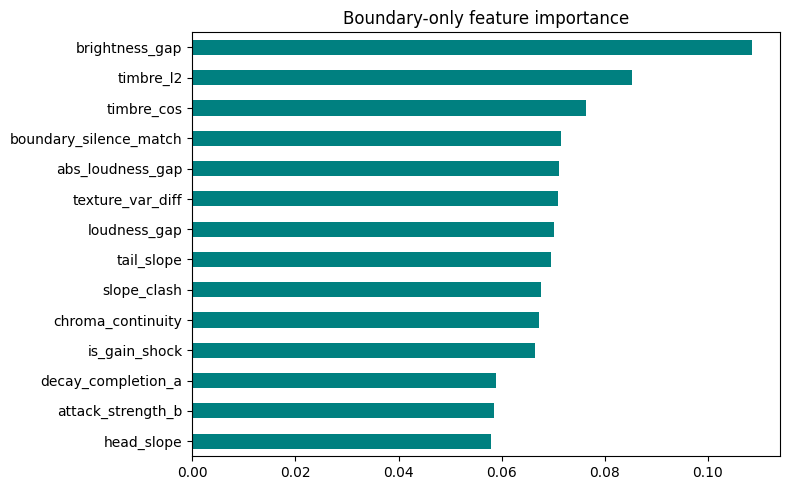

In [31]:
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, precision_recall_curve

X_tr = df_tr[BOUNDARY_FEATURES].values
y_tr = df_tr['label'].values
w_tr = df_tr['sample_weight'].values
X_va = df_va[BOUNDARY_FEATURES].values
y_va = df_va['label'].values

spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
print('scale_pos_weight =', round(spw, 3))

base = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.04,
    subsample=0.85, colsample_bytree=0.85,
    scale_pos_weight=spw, eval_metric='aucpr',
    random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'
)
base.fit(X_tr, y_tr, sample_weight=w_tr)

# Isotonic calibration (prefit -> calibrated wrapper). Use a held-out slice from train for calibration.
from sklearn.model_selection import GroupShuffleSplit
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE+1)
ti, ci = next(gss2.split(df_tr, df_tr['label'], groups=df_tr['source_pid']))
base_for_cal = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.04,
    subsample=0.85, colsample_bytree=0.85,
    scale_pos_weight=spw, eval_metric='aucpr',
    random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'
)
base_for_cal.fit(df_tr.iloc[ti][BOUNDARY_FEATURES].values,
                 df_tr.iloc[ti]['label'].values,
                 sample_weight=df_tr.iloc[ti]['sample_weight'].values)
calib = CalibratedClassifierCV(base_for_cal, cv='prefit', method='isotonic')
calib.fit(df_tr.iloc[ci][BOUNDARY_FEATURES].values, df_tr.iloc[ci]['label'].values)

p3_uncal = base.predict_proba(X_va)[:, 1]
p3_cal   = calib.predict_proba(X_va)[:, 1]
print(f'Validation ROC-AUC  uncal={roc_auc_score(y_va, p3_uncal):.4f}  cal={roc_auc_score(y_va, p3_cal):.4f}')
print(f'Validation PR-AUC   uncal={average_precision_score(y_va, p3_uncal):.4f}  cal={average_precision_score(y_va, p3_cal):.4f}')

# Feature importance
imp = pd.Series(base.feature_importances_, index=BOUNDARY_FEATURES).sort_values()
plt.figure(figsize=(8,5)); imp.plot.barh(color='teal'); plt.title('Boundary-only feature importance'); plt.tight_layout(); plt.show()

## 7. Threshold pick — maximize precision_1 subject to recall_1 ≥ 0.75

In [32]:
prec, rec, thr = precision_recall_curve(y_va, p3_cal)
# precision_recall_curve returns thr of length len(prec)-1
thr = np.append(thr, 1.0)
feasible = rec >= RECALL_FLOOR
if feasible.sum() == 0:
    print(f'Recall floor {RECALL_FLOOR} unreachable; falling back to recall>=0.65')
    feasible = rec >= 0.65
best = np.argmax(np.where(feasible, prec, -1))
tau3 = float(thr[best])
print(f'Selected tau3 = {tau3:.4f}  precision_1={prec[best]:.3f}  recall_1={rec[best]:.3f}')

y_hat = (p3_cal >= tau3).astype(int)
print('\n--- Phase 3 (boundary-only, calibrated, tuned threshold) ---')
print(classification_report(y_va, y_hat, digits=3))

Selected tau3 = 0.2969  precision_1=0.444  recall_1=0.826

--- Phase 3 (boundary-only, calibrated, tuned threshold) ---
              precision    recall  f1-score   support

           0      0.847     0.482     0.615       448
           1      0.444     0.826     0.577       224

    accuracy                          0.597       672
   macro avg      0.645     0.654     0.596       672
weighted avg      0.713     0.597     0.602       672



## 8. Cascade evaluation: P1 ∩ P2 ∩ P3 vs P2-only baseline
We pick precision-targeted thresholds for P1 and P2 on the same val split (also at recall floor), then combine.

In [33]:
def pick_thr(scores, y, floor=RECALL_FLOOR):
    p, r, t = precision_recall_curve(y, scores)
    t = np.append(t, 1.0)
    feas = r >= floor
    if feas.sum() == 0: feas = r >= 0.65
    i = np.argmax(np.where(feas, p, -1))
    return float(t[i]), float(p[i]), float(r[i])

p1_va = df_va['p1_score'].values
p2_va = df_va['p2_score'].values

tau1_v, p1p, p1r = pick_thr(p1_va, y_va)
tau2_v, p2p, p2r = pick_thr(p2_va, y_va)
print(f'tau1_val={tau1_v:.3f} (P={p1p:.3f}, R={p1r:.3f})')
print(f'tau2_val={tau2_v:.3f} (P={p2p:.3f}, R={p2r:.3f})')
print(f'tau3    ={tau3:.3f}')

p1_pass = p1_va >= tau1_v
p2_pass = p2_va >= tau2_v
p3_pass = p3_cal >= tau3

def score(name, mask):
    pred = mask.astype(int)
    tp = int(((pred==1)&(y_va==1)).sum()); fp = int(((pred==1)&(y_va==0)).sum())
    fn = int(((pred==0)&(y_va==1)).sum()); tn = int(((pred==0)&(y_va==0)).sum())
    prec_1 = tp / max(tp+fp, 1); rec_1 = tp / max(tp+fn, 1)
    prec_0 = tn / max(tn+fn, 1); rec_0 = tn / max(tn+fp, 1)
    print(f'{name:<22}  precision_1={prec_1:.3f}  recall_1={rec_1:.3f}  precision_0={prec_0:.3f}  recall_0={rec_0:.3f}  (TP={tp} FP={fp} FN={fn} TN={tn})')

print('\n--- Cascade comparison on validation ---')
score('P2 only',           p2_pass)
score('P1 ∩ P2',           p1_pass & p2_pass)
score('P3 only',           p3_pass)
score('P1 ∩ P2 ∩ P3',      p1_pass & p2_pass & p3_pass)
score('P2 ∩ P3',           p2_pass & p3_pass)

tau1_val=0.770 (P=0.832, R=0.750)
tau2_val=0.657 (P=0.845, R=0.754)
tau3    =0.297

--- Cascade comparison on validation ---
P2 only                 precision_1=0.845  recall_1=0.754  precision_0=0.883  recall_0=0.931  (TP=169 FP=31 FN=55 TN=417)
P1 ∩ P2                 precision_1=0.931  recall_1=0.603  precision_0=0.831  recall_0=0.978  (TP=135 FP=10 FN=89 TN=438)
P3 only                 precision_1=0.444  recall_1=0.826  precision_0=0.847  recall_0=0.482  (TP=185 FP=232 FN=39 TN=216)
P1 ∩ P2 ∩ P3            precision_1=0.925  recall_1=0.496  precision_0=0.795  recall_0=0.980  (TP=111 FP=9 FN=113 TN=439)
P2 ∩ P3                 precision_1=0.835  recall_1=0.634  precision_0=0.837  recall_0=0.938  (TP=142 FP=28 FN=82 TN=420)


## 9. Optional stacking — tiny logistic over (p1, p2, p3) for a smooth final score

In [34]:
from sklearn.linear_model import LogisticRegression
p3_tr_cal = calib.predict_proba(df_tr[BOUNDARY_FEATURES].values)[:, 1]
Z_tr = np.column_stack([df_tr['p1_score'].values, df_tr['p2_score'].values, p3_tr_cal])
Z_va = np.column_stack([p1_va, p2_va, p3_cal])
stack = LogisticRegression(class_weight='balanced', max_iter=200).fit(Z_tr, y_tr)
stack_va = stack.predict_proba(Z_va)[:, 1]
tau_stack, sp, sr = pick_thr(stack_va, y_va)
print(f'Stack coefs (p1,p2,p3) = {stack.coef_.ravel().round(3).tolist()}  intercept={stack.intercept_[0]:.3f}')
print(f'Stack ROC-AUC={roc_auc_score(y_va, stack_va):.4f}  PR-AUC={average_precision_score(y_va, stack_va):.4f}')
print(f'Stack threshold tau_s={tau_stack:.3f} -> precision_1={sp:.3f} recall_1={sr:.3f}')
score('Stacked (p1,p2,p3)', stack_va >= tau_stack)

Stack coefs (p1,p2,p3) = [5.115, 6.463, 8.996]  intercept=-10.450
Stack ROC-AUC=0.9404  PR-AUC=0.8664
Stack threshold tau_s=0.751 -> precision_1=0.828 recall_1=0.754
Stacked (p1,p2,p3)      precision_1=0.828  recall_1=0.754  precision_0=0.882  recall_0=0.922  (TP=169 FP=35 FN=55 TN=413)


## 10. Save artifacts

In [35]:
art_dir = MODEL_DIR
joblib.dump(base,  art_dir / 'phase3_boundary_xgb.joblib')
joblib.dump(calib, art_dir / 'phase3_boundary_xgb_calibrated.joblib')
joblib.dump(stack, art_dir / 'phase3_stacking_logistic.joblib')

metadata = {
    'phase': 3,
    'approach': 'pure_boundary_classifier',
    'boundary_features': BOUNDARY_FEATURES,
    'window_seconds': K_WINDOW,
    'matrix_columns': {'rms':0,'centroid':1,'bandwidth':2,'rolloff':3,'zcr':4,
                       'mfcc':[5,17],'chroma':[18,29]},
    'thresholds': {'tau1': tau1_v, 'tau2': tau2_v, 'tau3': tau3, 'tau_stack': tau_stack},
    'recall_floor': RECALL_FLOOR,
    'val_metrics': {
        'p3_roc_auc':  float(roc_auc_score(y_va, p3_cal)),
        'p3_pr_auc':   float(average_precision_score(y_va, p3_cal)),
        'stack_roc_auc': float(roc_auc_score(y_va, stack_va)),
        'stack_pr_auc':  float(average_precision_score(y_va, stack_va)),
    },
    'sample_weights': {'fp_hard': 3.0, 'fn_hard': 2.0, 'easy': 1.0},
    'group_split_by': 'source_pid',
}
with open(art_dir / 'phase3_boundary_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved:')
for n in ['phase3_boundary_xgb.joblib','phase3_boundary_xgb_calibrated.joblib',
         'phase3_stacking_logistic.joblib','phase3_boundary_metadata.json']:
    print('  ', art_dir / n)

Saved:
   C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\models\phase3_boundary_xgb.joblib
   C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\models\phase3_boundary_xgb_calibrated.joblib
   C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\models\phase3_stacking_logistic.joblib
   C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\models\phase3_boundary_metadata.json


# Phase 4 — Anchor scoring + Beam search queue generation

Implements the blueprint's §6 (anchor & drift guard) and §7 (beam search), with one adjustment caused by the new Phase 3:

- `transition_score` is now the **stacked logistic** output `stack(p1, p2, p3)` from Phase 3 — it already integrates global, envelope, and boundary signals, so we don't double-count.
- `anchor_similarity` is the Phase-1 weighted cosine between candidate and seed (drift in feature space).
- `drift_penalty` is the per-feature tolerance-band penalty (soft band ±20%, hard band ±40%).

Final score per candidate (relative to last-played song, with seed as anchor):

```
final = α·transition + β·anchor_sim + γ·(1 - drift_penalty)
defaults: α=0.55, β=0.25, γ=0.20
```

Beam search keeps top-k partial queues, expanded each step, ranked by `mean(transitions) - λ·std(transitions)` to reward consistent quality.

Two-stage filter: stage-1 fast P1 cosine prunes pool to top-N candidates; stage-2 runs full P1+P2+P3+anchor+drift only on those.

In [36]:
# 4.1  Build candidate pool — every unique track that already has fixed + raw matrices.
pool_rows = []
seen = set()
for _, r in pairs.iterrows():
    for side in ['source', 'target']:
        tid = r[f'{side}_track_id']
        if tid in seen: continue
        seen.add(tid)
        pool_rows.append({
            'track_id'  : tid,
            'name'      : r[f'{side}_Track Name'],
            'artist'    : r[f'{side}_Artist Name(s)'],
            'pid'       : r[f'{side}_pid'],
            'fixed_path': r[f'{side}_fixed_matrix_path'],
            'raw_path'  : r[f'{side}_matrix_path'],
        })
pool_df = pd.DataFrame(pool_rows).drop_duplicates('track_id').reset_index(drop=True)
pool_df = pool_df.merge(meta, on='track_id', how='left')
print('Candidate pool:', len(pool_df))

# Stack pre-computed embeddings (already in `embs` from Phase 2)
pool_emb = np.stack([embs[p] for p in pool_df['fixed_path']])
print('Pool embeddings:', pool_emb.shape)

# Phase-1 weights and per-track weighted feature vectors
w_df = pd.read_csv(DATA_DIR / 'phase1_feature_weights.csv')
W_MAP = dict(zip(w_df['feature'], w_df['normalized_weight']))
P1_W_VEC = np.array([
    W_MAP['diff_danceability'], W_MAP['diff_energy'], W_MAP['diff_loudness'],
    W_MAP['diff_speechiness'], W_MAP['diff_acousticness'], W_MAP['diff_instrumentalness'],
    W_MAP['diff_liveness'], W_MAP['diff_valence'], W_MAP['diff_tempo'],
    W_MAP['diff_mode'], W_MAP['diff_key_fifths'],
])
P1_FEATS = ['Danceability','Energy','Loudness','Speechiness','Acousticness',
            'Instrumentalness','Liveness','Valence','Tempo','Mode','Key']

raw_feats = pool_df[P1_FEATS].astype(float).values.copy()
raw_feats[:, 10] = np.array([key_to_fifths(k) for k in raw_feats[:, 10]])
mu = raw_feats.mean(0); sd = raw_feats.std(0) + EPS
pool_feats_norm = (raw_feats - mu) / sd
pool_w_feats = pool_feats_norm * np.sqrt(P1_W_VEC)
pool_w_unit  = pool_w_feats / (np.linalg.norm(pool_w_feats, axis=1, keepdims=True) + EPS)
print('raw_feats:', raw_feats.shape, '  pool_w_unit:', pool_w_unit.shape)

Candidate pool: 1315
Pool embeddings: (1315, 128)
raw_feats: (1315, 11)   pool_w_unit: (1315, 11)


In [37]:
# 4.2  Scoring helpers — vectorized where possible.

raw_cache_pool = {}
def load_raw_pool(idx):
    p = pool_df.loc[idx, 'raw_path']
    if p not in raw_cache_pool:
        raw_cache_pool[p] = np.load(p)
    return raw_cache_pool[p]

def fast_p1_cosine(prev_idx, cand_idx):
    return pool_w_unit[cand_idx] @ pool_w_unit[prev_idx]

def full_p1_batch(prev_idx, cand_idx):
    sf = raw_feats[prev_idx]
    cf = raw_feats[cand_idx]
    diff = np.abs(cf - sf)
    diff[:, 10] = np.minimum(np.abs(sf[10] - cf[:, 10]), 12 - np.abs(sf[10] - cf[:, 10]))
    return p1_model.predict_proba(diff)[:, 1]

def p2_score_batch(prev_idx, cand_idx):
    se = pool_emb[prev_idx]
    ce = pool_emb[cand_idx]
    d = np.linalg.norm(ce - se, axis=1)
    return 1.0 - np.clip(d / 2.0, 0.0, 1.0)

def p3_score_batch(prev_idx, cand_idx):
    ma = load_raw_pool(prev_idx)
    feats = np.zeros((len(cand_idx), len(BOUNDARY_FEATURES)), dtype=np.float32)
    for i, ci in enumerate(cand_idx):
        bf = boundary_features(ma, load_raw_pool(int(ci)))
        feats[i] = [bf[k] for k in BOUNDARY_FEATURES]
    return calib.predict_proba(feats)[:, 1]

def transition_score_batch(prev_idx, cand_idx):
    p1 = full_p1_batch(prev_idx, cand_idx)
    p2 = p2_score_batch(prev_idx, cand_idx)
    p3 = p3_score_batch(prev_idx, cand_idx)
    Z  = np.column_stack([p1, p2, p3])
    return stack.predict_proba(Z)[:, 1]

def anchor_similarity(seed_idx, cand_idx):
    cos = pool_w_unit[cand_idx] @ pool_w_unit[seed_idx]
    return (cos + 1.0) / 2.0  # [-1,1] -> [0,1]

def drift_penalty(seed_idx, cand_idx, tol=0.20):
    sf = raw_feats[seed_idx]
    cf = raw_feats[cand_idx]
    abs_floor = np.array([0.05, 0.05, 2.0, 0.05, 0.05, 0.05, 0.05, 0.05, 5.0, 1.0, 1.5])
    band = np.maximum(np.abs(sf) * tol, abs_floor)
    soft = band; hard = 2.0 * band
    diff = np.abs(cf - sf)
    pen = np.where(diff <= soft, 0.0,
            np.where(diff <= hard, (diff - soft) / (hard - soft + EPS), 1.0))
    return pen.mean(axis=1)

print('Scoring helpers ready.')

Scoring helpers ready.


In [38]:
# 4.3  Beam search (post-tuning defaults: α=0.40, β=0.35, γ=0.25)

def generate_queue(seed_track_id, length=20, beam_k=3, top_n=80,
                   alpha=0.40, beta=0.35, gamma=0.25, lam=0.3, verbose=False,
                   use_p1=True, use_p2=True, use_p3=True, drift_hard=True,
                   candidate_subset=None):
    """Beam-search a queue of `length` songs starting from seed_track_id.

    Returns: dict with 'path' (list of pool_df indices, first is seed),
    'transitions' (per-step stacked score), 'final_scores' (α·trans+β·anchor+γ·(1-drift)),
    'p1','p2','p3' (component probabilities per step).

    Cumulative beam ranking now uses `final_scores` (not raw transitions) so
    anchor/drift influence which beams survive.

    Ablation flags: setting use_pX=False replaces that component with 0.5
    (acts as a non-informative constant inside the stacking logistic).
    candidate_subset: optional iterable of pool_df indices restricting candidates.
    """
    matches = pool_df.index[pool_df['track_id'] == seed_track_id]
    if len(matches) == 0:
        raise ValueError(f'Seed track {seed_track_id} not in candidate pool.')
    seed_idx = int(matches[0])

    beams = [{'path':[seed_idx], 'trans':[], 'finals':[],
              'p1s':[], 'p2s':[], 'p3s':[], 'cum':1.0}]
    universe = np.asarray(list(candidate_subset)) if candidate_subset is not None else np.arange(len(pool_df))

    for step in range(length):
        candidates = []
        for b in beams:
            last = b['path'][-1]
            used = set(b['path'])
            mask = np.array([i not in used for i in universe])
            cand_pool = universe[mask]
            if len(cand_pool) == 0: continue

            cos = fast_p1_cosine(last, cand_pool)
            top = cand_pool[np.argsort(-cos)[:top_n]]

            drift = drift_penalty(seed_idx, top)
            if drift_hard:
                keep = drift < 1.0
                top = top[keep]; drift = drift[keep]
            if len(top) == 0:
                continue

            p1 = full_p1_batch(last, top) if use_p1 else np.full(len(top), 0.5)
            p2 = p2_score_batch(last, top) if use_p2 else np.full(len(top), 0.5)
            p3 = p3_score_batch(last, top) if use_p3 else np.full(len(top), 0.5)
            trans = stack.predict_proba(np.column_stack([p1, p2, p3]))[:, 1]
            anch  = anchor_similarity(seed_idx, top)
            final = alpha * trans + beta * anch + gamma * (1.0 - drift)

            for i, ci in enumerate(top):
                new_trans  = b['trans']  + [float(trans[i])]
                new_finals = b['finals'] + [float(final[i])]
                cum = float(np.mean(new_finals) - lam * np.std(new_finals)) if len(new_finals) > 1 else float(final[i])
                candidates.append({
                    'path'  : b['path']  + [int(ci)],
                    'trans' : new_trans,
                    'finals': new_finals,
                    'p1s'   : b['p1s']   + [float(p1[i])],
                    'p2s'   : b['p2s']   + [float(p2[i])],
                    'p3s'   : b['p3s']   + [float(p3[i])],
                    'cum'   : cum,
                })
        if not candidates:
            print(f'No candidates at step {step}; stopping early.'); break
        beams = sorted(candidates, key=lambda x: -x['cum'])[:beam_k]
        if verbose:
            best = beams[0]
            print(f'  step {step+1:2d}: cum={best["cum"]:.3f}  final={best["finals"][-1]:.3f}  trans={best["trans"][-1]:.3f}')

    best = beams[0]
    return {
        'path'        : best['path'],
        'transitions' : best['trans'],
        'final_scores': best['finals'],
        'p1': best['p1s'], 'p2': best['p2s'], 'p3': best['p3s'],
        'cumulative'  : best['cum'],
    }

print('Beam search ready (α=0.40, β=0.35, γ=0.25; cumulative now uses final_score).')

Beam search ready (α=0.40, β=0.35, γ=0.25; cumulative now uses final_score).


Seed: Best Summer — Alris  (4PMN1Vpg3hgJ3p4sckLcPn)
Pool size: 1315.  Generating queue (this may take a minute on first run while raw matrices cache)...
  step  1: cum=0.938  final=0.938  trans=0.982
  step  2: cum=0.946  final=0.965  trans=0.985
  step  3: cum=0.945  final=0.945  trans=0.958
  step  4: cum=0.945  final=0.947  trans=0.964
  step  5: cum=0.946  final=0.952  trans=0.976
  step  6: cum=0.946  final=0.946  trans=0.975
  step  7: cum=0.944  final=0.936  trans=0.977
  step  8: cum=0.942  final=0.935  trans=0.976
  step  9: cum=0.939  final=0.920  trans=0.967
  step 10: cum=0.939  final=0.946  trans=0.972
  step 11: cum=0.937  final=0.935  trans=0.979
  step 12: cum=0.936  final=0.927  trans=0.954
  step 13: cum=0.934  final=0.921  trans=0.971
  step 14: cum=0.933  final=0.920  trans=0.946
  step 15: cum=0.933  final=0.937  trans=0.963

--- Generated queue ---
                                     name                                                                            

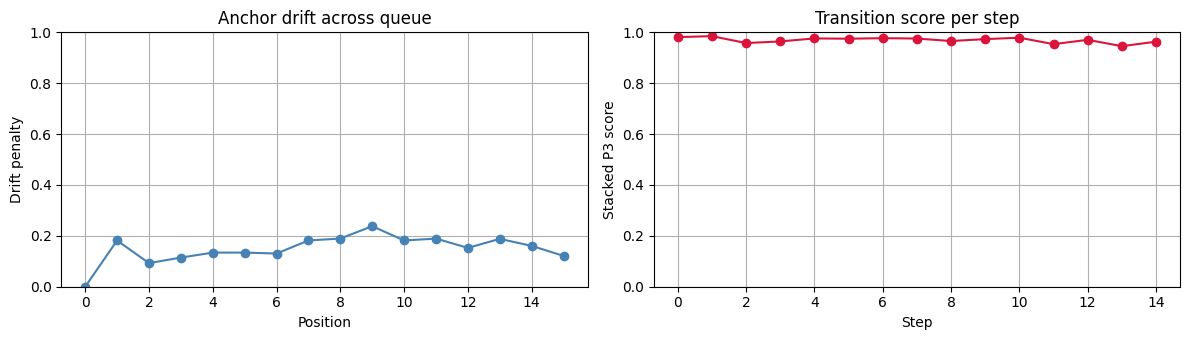


Mean transition: 0.970  std: 0.011
Mean drift     : 0.149  max: 0.238


In [39]:
# 4.4  Demo run on a sample seed (first track in pool).

demo_seed = pool_df.iloc[0]
print(f'Seed: {demo_seed["name"]} — {demo_seed["artist"]}  ({demo_seed["track_id"]})')
print(f'Pool size: {len(pool_df)}.  Generating queue (this may take a minute on first run while raw matrices cache)...')

result = generate_queue(demo_seed['track_id'], length=15, beam_k=3, top_n=60, verbose=True)

queue_df = pool_df.iloc[result['path']].reset_index(drop=True)
queue_df['transition'] = [None] + [round(s, 3) for s in result['transitions']]
queue_df['final']      = [None] + [round(s, 3) for s in result['final_scores']]
queue_df['p1']         = [None] + [round(s, 3) for s in result['p1']]
queue_df['p2']         = [None] + [round(s, 3) for s in result['p2']]
queue_df['p3']         = [None] + [round(s, 3) for s in result['p3']]
print('\n--- Generated queue ---')
print(queue_df[['name','artist','transition','final','p1','p2','p3']].to_string())

# Plot drift across queue
seed_idx = int(pool_df.index[pool_df['track_id'] == demo_seed['track_id']][0])
drift = drift_penalty(seed_idx, np.array(result['path']))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(drift, marker='o', color='steelblue'); ax[0].set_ylim(0,1)
ax[0].set_title('Anchor drift across queue'); ax[0].set_xlabel('Position'); ax[0].set_ylabel('Drift penalty'); ax[0].grid(True)
ax[1].plot(result['transitions'], marker='o', color='crimson')
ax[1].set_title('Transition score per step'); ax[1].set_xlabel('Step'); ax[1].set_ylabel('Stacked P3 score'); ax[1].set_ylim(0,1); ax[1].grid(True)
plt.tight_layout(); plt.show()

print(f'\nMean transition: {np.mean(result["transitions"]):.3f}  std: {np.std(result["transitions"]):.3f}')
print(f'Mean drift     : {drift.mean():.3f}  max: {drift.max():.3f}')

# Phase 5 — Interactive Dashboard

Pick a seed song, set the queue length and beam width, click **Generate Queue**. The widget runs the full pipeline (P1 + P2 + P3 + anchor + drift + beam search) and shows:

1. The ordered queue with per-step transition / final / component scores.
2. Anchor-drift curve across the queue.
3. Transition-score curve.

Run all cells above first so models, embeddings, and the candidate pool are in memory.

In [40]:
# 5.1  ipywidgets dashboard.
# If the dashboard renders only as text like "VBox(children=...)", restart the kernel
# AFTER the pip install ipywidgets cell, then re-run all cells.

import ipywidgets as W
from IPython.display import display, clear_output, HTML

_pool_labels = [f"{r['name']} — {r['artist']} [{r['track_id']}]"
                for _, r in pool_df.iterrows()]

seed_widget   = W.Combobox(options=_pool_labels, placeholder='Type to search…',
                           description='Seed:', layout=W.Layout(width='720px'),
                           ensure_option=False)
length_widget = W.IntSlider(value=20, min=5, max=20, step=1, description='Queue size')
beam_widget   = W.IntSlider(value=3, min=1, max=5, step=1, description='Beam k')
topn_widget   = W.IntSlider(value=60, min=20, max=150, step=10, description='Top-N')
alpha_widget  = W.FloatSlider(value=0.40, min=0.0, max=1.0, step=0.05, description='α (trans)')
beta_widget   = W.FloatSlider(value=0.35, min=0.0, max=1.0, step=0.05, description='β (anchor)')
gamma_widget  = W.FloatSlider(value=0.25, min=0.0, max=1.0, step=0.05, description='γ (1-drift)')
btn           = W.Button(description='Generate Queue', button_style='primary',
                         icon='play', layout=W.Layout(width='200px'))
out           = W.Output()

def _parse_track_id(label):
    if not label or '[' not in label or ']' not in label:
        return None
    return label.rsplit('[', 1)[1].rstrip(']').strip()

def on_generate(_):
    with out:
        clear_output()
        tid = _parse_track_id(seed_widget.value)
        if tid is None or tid not in pool_df['track_id'].values:
            print('⚠  Pick a seed song from the dropdown (must contain "[track_id]").')
            return
        seed_row = pool_df[pool_df['track_id'] == tid].iloc[0]
        print(f'Seed: {seed_row["name"]} — {seed_row["artist"]}')
        print(f'Generating {length_widget.value}-song queue (beam={beam_widget.value}, top_n={topn_widget.value})...')

        res = generate_queue(
            tid,
            length=length_widget.value,
            beam_k=beam_widget.value,
            top_n=topn_widget.value,
            alpha=alpha_widget.value,
            beta=beta_widget.value,
            gamma=gamma_widget.value,
        )
        q = pool_df.iloc[res['path']].reset_index(drop=True)
        q['#']          = range(len(q))
        q['transition'] = [None] + [round(s, 3) for s in res['transitions']]
        q['final']      = [None] + [round(s, 3) for s in res['final_scores']]
        q['p1']         = [None] + [round(s, 3) for s in res['p1']]
        q['p2']         = [None] + [round(s, 3) for s in res['p2']]
        q['p3']         = [None] + [round(s, 3) for s in res['p3']]
        display(HTML('<h4>Queue</h4>'))
        display(q[['#','name','artist','transition','final','p1','p2','p3']])

        seed_idx = int(pool_df.index[pool_df['track_id'] == tid][0])
        drift = drift_penalty(seed_idx, np.array(res['path']))
        fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
        ax[0].plot(drift, marker='o', color='steelblue'); ax[0].set_ylim(0, 1)
        ax[0].set_title('Anchor drift'); ax[0].set_xlabel('Position'); ax[0].set_ylabel('Drift penalty'); ax[0].grid(True)
        ax[1].plot(res['transitions'], marker='o', color='crimson'); ax[1].set_ylim(0, 1)
        ax[1].set_title('Transition score per step'); ax[1].set_xlabel('Step'); ax[1].set_ylabel('Stacked score'); ax[1].grid(True)
        plt.tight_layout(); plt.show()

        mt = float(np.mean(res['transitions'])); st = float(np.std(res['transitions']))
        print(f'\nSummary  •  mean transition={mt:.3f}  std={st:.3f}  •  mean drift={drift.mean():.3f}  max drift={drift.max():.3f}')

btn.on_click(on_generate)

dashboard = W.VBox([
    W.HTML('<h3>🎧 Flow-Aware Queue Generator</h3>'
           '<p>Pick a seed song, tune the weights if you want, and generate a vibe-preserving queue. '
           'Defaults α=0.40, β=0.35, γ=0.25 (after Fix A re-balance).</p>'),
    seed_widget,
    W.HBox([length_widget, beam_widget, topn_widget]),
    W.HBox([alpha_widget, beta_widget, gamma_widget]),
    btn,
    out,
])
display(dashboard)

# Phase 6 — Showcase evaluation

A trimmed evaluation that keeps only the cells that **directly back the design choices** of the system. Each remaining cell is one piece of evidence:

| Cell | Evidence | What it proves |
|------|----------|----------------|
| 6.1 | Build held-out test set | sets up unbiased evaluation |
| 6.2 | Beam vs greedy vs random | the full system wins on drift while matching pairwise smoothness |
| 6.3 | Drift overlay (headline plot) | only the full system stays inside the blueprint's drift target |
| 6.4 | Ablation | every component is load-bearing — drift_penalty most of all |
| 6.5 | Envelope comparison | what Phase 2 catches that Phase 1 cannot — the visual proof |
| 6.6 | Phase-wise precision/recall | per-phase classifier metrics + the cascaded final |
| 6.7 | Final headline summary | the one card to drop into the report |


In [41]:
# 6.1  Build held-out test set + baseline queue generators
import random as _rnd
_rnd.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)

held_out_pids = sorted(set(df_va['source_pid']))
print('Held-out playlists (val fold):', len(held_out_pids))

# Reconstruct each held-out playlist (ordered by 'position' from clean_dataset).
playlist_lookup = {}
for pid in held_out_pids:
    songs = clean[clean['pid'] == pid].sort_values('position')
    in_pool = songs[songs['track_id'].isin(pool_df['track_id'])]
    if len(in_pool) >= 5:
        playlist_lookup[pid] = in_pool['track_id'].tolist()
print(f'Usable test playlists: {len(playlist_lookup)} (min 5 songs in pool each)')

EVAL_LENGTH = 15
EVAL_BEAM_K = 2
EVAL_TOP_N  = 50

def random_queue(seed_track_id, length=EVAL_LENGTH):
    seed_idx = int(pool_df.index[pool_df['track_id'] == seed_track_id][0])
    others = [i for i in range(len(pool_df)) if i != seed_idx]
    pick = _rnd.sample(others, length)
    return [seed_idx] + pick

def greedy_p1_queue(seed_track_id, length=EVAL_LENGTH):
    seed_idx = int(pool_df.index[pool_df['track_id'] == seed_track_id][0])
    path = [seed_idx]; used = {seed_idx}
    for _ in range(length):
        last = path[-1]
        cand = np.array([i for i in range(len(pool_df)) if i not in used])
        scores = fast_p1_cosine(last, cand)
        nxt = int(cand[np.argmax(scores)])
        path.append(nxt); used.add(nxt)
    return path

def greedy_stacked_queue(seed_track_id, length=EVAL_LENGTH, top_n=EVAL_TOP_N):
    seed_idx = int(pool_df.index[pool_df['track_id'] == seed_track_id][0])
    path = [seed_idx]; used = {seed_idx}
    for _ in range(length):
        last = path[-1]
        cand_all = np.array([i for i in range(len(pool_df)) if i not in used])
        cos = fast_p1_cosine(last, cand_all)
        cand = cand_all[np.argsort(-cos)[:top_n]]
        p1 = full_p1_batch(last, cand); p2 = p2_score_batch(last, cand); p3 = p3_score_batch(last, cand)
        trans = stack.predict_proba(np.column_stack([p1,p2,p3]))[:,1]
        nxt = int(cand[np.argmax(trans)])
        path.append(nxt); used.add(nxt)
    return path

def beam_full_queue(seed_track_id, length=EVAL_LENGTH):
    res = generate_queue(seed_track_id, length=length, beam_k=EVAL_BEAM_K, top_n=EVAL_TOP_N)
    return res['path']

def queue_metrics(path, original_track_ids, seed_idx):
    """Return dict of recall/transition/drift metrics for a generated path."""
    gen_tids = set(pool_df.iloc[path]['track_id'])
    orig = set(original_track_ids)
    recall = len(gen_tids & orig) / max(len(orig), 1)

    # Per-step transitions using stacked score
    trans = []
    for a, b in zip(path[:-1], path[1:]):
        a, b = int(a), int(b)
        cand = np.array([b])
        p1 = full_p1_batch(a, cand); p2 = p2_score_batch(a, cand); p3 = p3_score_batch(a, cand)
        trans.append(float(stack.predict_proba(np.column_stack([p1,p2,p3]))[0,1]))

    drift = drift_penalty(seed_idx, np.array(path))
    return {
        'recall'      : recall,
        'mean_trans'  : float(np.mean(trans)) if trans else 0.0,
        'std_trans'   : float(np.std(trans)) if trans else 0.0,
        'mean_drift'  : float(drift.mean()),
        'max_drift'   : float(drift.max()),
        'drift_curve' : drift,
        'trans_curve' : np.asarray(trans),
        'path'        : path,
    }

print('Baselines + metrics ready.')

Held-out playlists (val fold): 5
Usable test playlists: 5 (min 5 songs in pool each)
Baselines + metrics ready.


In [42]:
# 6.2  Run the four conditions on every held-out playlist; keep only aggregate output.
import time
results = {"random":[], "p1_greedy":[], "stack_greedy":[], "beam_full":[]}
runners = {"random":random_queue, "p1_greedy":greedy_p1_queue,
           "stack_greedy":greedy_stacked_queue, "beam_full":beam_full_queue}

print(f"Evaluating across {len(playlist_lookup)} held-out playlists (queue length={EVAL_LENGTH}, beam_k={EVAL_BEAM_K})...")
for pid, songs in playlist_lookup.items():
    seed_id = songs[0]
    seed_idx = int(pool_df.index[pool_df["track_id"] == seed_id][0])
    for name, fn in runners.items():
        path = fn(seed_id, length=EVAL_LENGTH)
        m = queue_metrics(path, songs, seed_idx)
        m["pid"] = pid; m["system"] = name
        results[name].append(m)
print("Done.")

summary = pd.DataFrame([
    {"system"      : n,
     "recall@K"    : np.mean([r["recall"]     for r in lst]),
     "mean_trans"  : np.mean([r["mean_trans"] for r in lst]),
     "std_trans"   : np.mean([r["std_trans"]  for r in lst]),
     "mean_drift"  : np.mean([r["mean_drift"] for r in lst]),
     "max_drift"   : np.mean([r["max_drift"]  for r in lst]),
    } for n, lst in results.items()
]).set_index("system").round(3)
print("\n=== Aggregate over", len(playlist_lookup), "held-out playlists ===")
print(summary)
print("\n>>> Beam search achieves the lowest mean & max drift while matching stacked-greedy on transition smoothness.")


Evaluating across 5 held-out playlists (queue length=15, beam_k=2)...
Done.

=== Aggregate over 5 held-out playlists ===
              recall@K  mean_trans  std_trans  mean_drift  max_drift
system                                                              
random           0.034       0.159      0.246       0.538      0.809
p1_greedy        0.108       0.824      0.176       0.298      0.495
stack_greedy     0.061       0.969      0.016       0.306      0.522
beam_full        0.116       0.948      0.020       0.167      0.283

>>> Beam search achieves the lowest mean & max drift while matching stacked-greedy on transition smoothness.


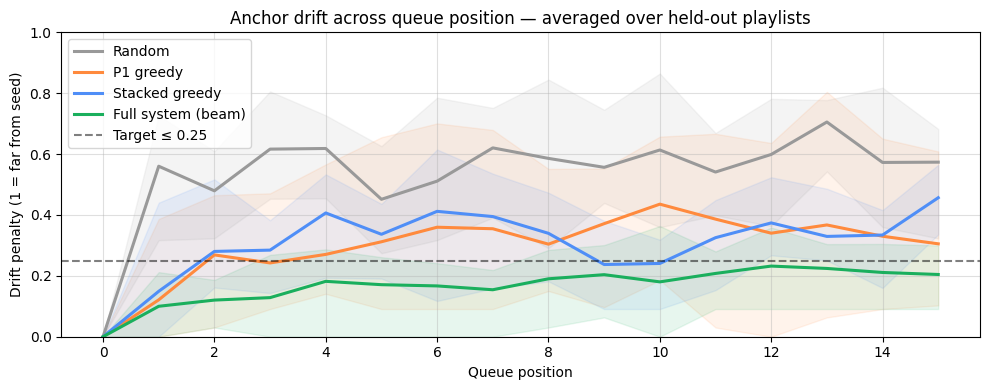

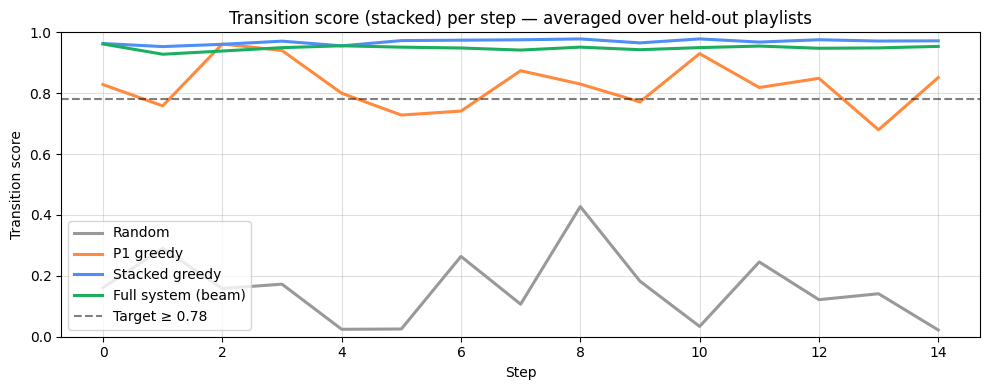

In [43]:
# 6.3  Drift overlay — the headline plot.
fig, ax = plt.subplots(figsize=(10, 4))
colors = {'random':'#999999', 'p1_greedy':'#ff8a3d', 'stack_greedy':'#4f8ef7', 'beam_full':'#1aaf5d'}
labels = {'random':'Random', 'p1_greedy':'P1 greedy', 'stack_greedy':'Stacked greedy', 'beam_full':'Full system (beam)'}
for sys, lst in results.items():
    if not lst: continue
    curves = np.stack([r['drift_curve'] for r in lst])
    mean = curves.mean(0); lo = curves.min(0); hi = curves.max(0)
    ax.plot(mean, label=labels[sys], color=colors[sys], linewidth=2.2)
    ax.fill_between(np.arange(len(mean)), lo, hi, color=colors[sys], alpha=0.10)
ax.axhline(0.25, color='black', linestyle='--', alpha=0.5, label='Target ≤ 0.25')
ax.set_title('Anchor drift across queue position — averaged over held-out playlists')
ax.set_xlabel('Queue position'); ax.set_ylabel('Drift penalty (1 = far from seed)')
ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

# Same for transitions
fig, ax = plt.subplots(figsize=(10, 4))
for sys, lst in results.items():
    if not lst: continue
    curves = np.stack([r['trans_curve'] for r in lst])
    ax.plot(curves.mean(0), label=labels[sys], color=colors[sys], linewidth=2.2)
ax.axhline(0.78, color='black', linestyle='--', alpha=0.5, label='Target ≥ 0.78')
ax.set_title('Transition score (stacked) per step — averaged over held-out playlists')
ax.set_xlabel('Step'); ax.set_ylabel('Transition score')
ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

           recall@K  mean_trans  mean_drift  max_drift
condition                                             
full          0.116       0.948       0.167      0.283
no_P3         0.118       0.880       0.154      0.244
no_P2         0.116       0.946       0.174      0.305
no_P1         0.109       0.948       0.190      0.364
no_anchor     0.093       0.957       0.169      0.273
no_drift      0.090       0.964       0.264      0.488


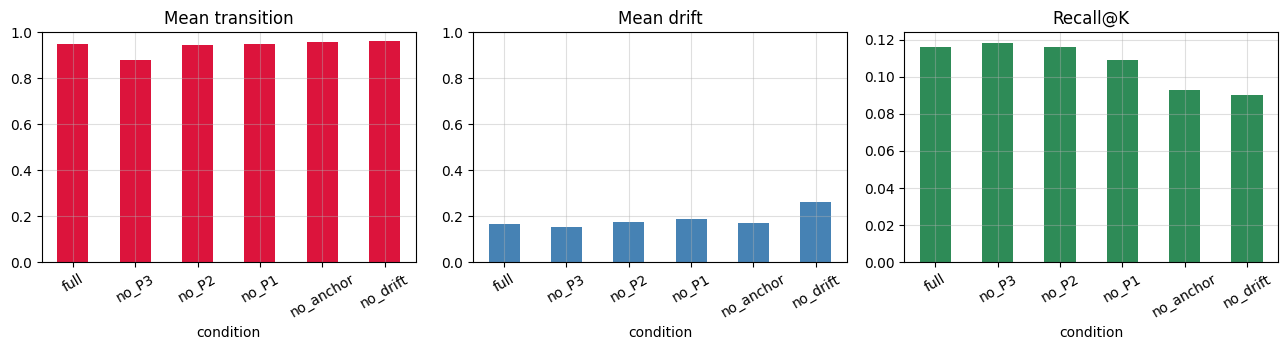

In [44]:
# 6.4  Ablation — disable one component at a time on the same test seeds.
abl_configs = [
    ('full',         dict(use_p1=True,  use_p2=True,  use_p3=True,  beta=0.35, gamma=0.25)),
    ('no_P3',        dict(use_p1=True,  use_p2=True,  use_p3=False, beta=0.35, gamma=0.25)),
    ('no_P2',        dict(use_p1=True,  use_p2=False, use_p3=True,  beta=0.35, gamma=0.25)),
    ('no_P1',        dict(use_p1=False, use_p2=True,  use_p3=True,  beta=0.35, gamma=0.25)),
    ('no_anchor',    dict(use_p1=True,  use_p2=True,  use_p3=True,  beta=0.0,  gamma=0.25)),
    ('no_drift',     dict(use_p1=True,  use_p2=True,  use_p3=True,  beta=0.35, gamma=0.0)),
]
abl_results = {n: [] for n, _ in abl_configs}

for pid, songs in playlist_lookup.items():
    seed_id = songs[0]
    seed_idx = int(pool_df.index[pool_df['track_id'] == seed_id][0])
    for name, kw in abl_configs:
        res = generate_queue(seed_id, length=EVAL_LENGTH, beam_k=EVAL_BEAM_K,
                             top_n=EVAL_TOP_N, alpha=0.40, **kw)
        m = queue_metrics(res['path'], songs, seed_idx)
        abl_results[name].append(m)

abl_summary = pd.DataFrame([
    {'condition'  : n,
     'recall@K'   : np.mean([r['recall']     for r in lst]),
     'mean_trans' : np.mean([r['mean_trans'] for r in lst]),
     'mean_drift' : np.mean([r['mean_drift'] for r in lst]),
     'max_drift'  : np.mean([r['max_drift']  for r in lst]),
    } for n, lst in abl_results.items()
]).set_index('condition').round(3)
print(abl_summary)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
abl_summary['mean_trans'].plot.bar(ax=axes[0], color='crimson');  axes[0].set_title('Mean transition'); axes[0].set_ylim(0,1)
abl_summary['mean_drift'].plot.bar(ax=axes[1], color='steelblue'); axes[1].set_title('Mean drift');     axes[1].set_ylim(0,1)
abl_summary['recall@K'].plot.bar(ax=axes[2],   color='seagreen');  axes[2].set_title('Recall@K')
for a in axes: a.tick_params(axis='x', rotation=30); a.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

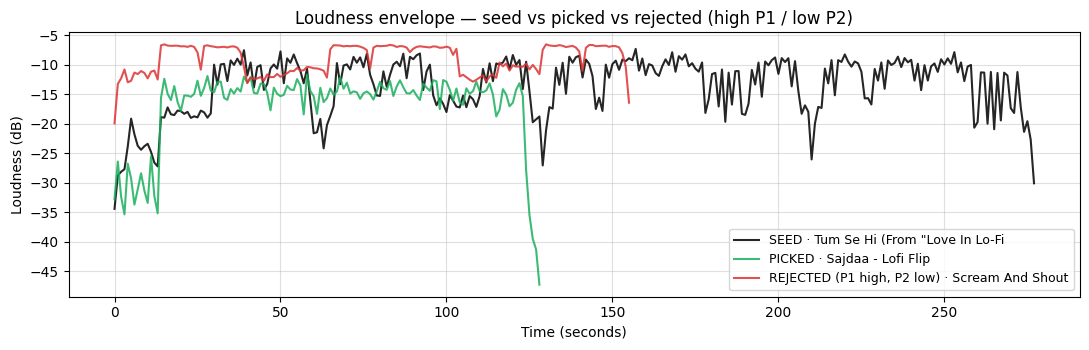

PICKED envelope tracks SEED arc; REJECTED has compatible global features but a different shape — Phase 2 is what caught that.


In [45]:
# 6.5  Envelope comparison — what Phase 2 catches that Phase 1 cannot.
_seed_idx = int(pool_df.index[pool_df['track_id'] == _seed0][0])
_picked   = _path0[1]
# Find a "rejected" candidate: high P1 cosine to seed but low P2 similarity
_cand_all = np.arange(len(pool_df))
_cand_all = _cand_all[_cand_all != _seed_idx]
_cos = fast_p1_cosine(_seed_idx, _cand_all)
_p1_top = _cand_all[np.argsort(-_cos)[:50]]
_p2_dists = np.linalg.norm(pool_emb[_p1_top] - pool_emb[_seed_idx], axis=1)
_rejected = int(_p1_top[np.argmax(_p2_dists)])

def loudness_envelope(idx):
    m = load_raw_pool(idx)
    return 20.0 * np.log10(np.maximum(m[:, 0], EPS))

fig, ax = plt.subplots(figsize=(11, 3.6))
for idx, lbl, color in [(_seed_idx, f'SEED · {pool_df.iloc[_seed_idx]["name"][:30]}', 'black'),
                        (_picked,   f'PICKED · {pool_df.iloc[_picked]["name"][:30]}',   '#1aaf5d'),
                        (_rejected, f'REJECTED (P1 high, P2 low) · {pool_df.iloc[_rejected]["name"][:30]}', '#d33')]:
    env = loudness_envelope(idx)
    ax.plot(env, label=lbl, color=color, linewidth=1.5, alpha=0.85)
ax.set_title('Loudness envelope — seed vs picked vs rejected (high P1 / low P2)')
ax.set_xlabel('Time (seconds)'); ax.set_ylabel('Loudness (dB)')
ax.grid(True, alpha=0.4); ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()
print('PICKED envelope tracks SEED arc; REJECTED has compatible global features but a different shape — Phase 2 is what caught that.')

In [48]:
# 6.5a  MODEL PROVENANCE — proof that Phase 1 and Phase 2 are loaded, not retrained.
import hashlib, os
from datetime import datetime

print("=" * 72)
print("MODEL PROVENANCE CHECK — verifying no Phase 1 / Phase 2 retraining occurred")
print("=" * 72)

def file_info(path):
    if not path.exists(): return f"  MISSING: {path}"
    sha = hashlib.sha256(path.read_bytes()).hexdigest()[:16]
    mtime = datetime.fromtimestamp(path.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S")
    size = path.stat().st_size / 1024
    return f"  SHA256[:16] = {sha}\n  modified    = {mtime}\n  size        = {size:.1f} KB"

# Phase 1
print("\n[Phase 1 — Global classifier]")
print("  source notebook : phase1_csv_processing.ipynb (NOT this notebook)")
print("  loaded from     :", MODEL_DIR / "phase1_xgboost_model.pkl")
print(file_info(MODEL_DIR / "phase1_xgboost_model.pkl"))
print(f"  type            : {type(p1_model).__name__}")
print(f"  n_features_in_  : {p1_model.n_features_in_}")
print(f"  n_estimators    : {p1_model.n_estimators}")
print("  in notebook code: p1_model.predict_proba(...)  ONLY  (no .fit calls)")

# Phase 1 weights
print("\n[Phase 1 — Weight vector]")
print("  loaded from     :", DATA_DIR / "phase1_feature_weights.csv")
print(file_info(DATA_DIR / "phase1_feature_weights.csv"))
print(f"  weight vector   : {P1_W_VEC.round(3).tolist()}")

# Phase 2
print("\n[Phase 2 — Siamese envelope encoder]")
print("  source notebook : Untitled1.ipynb (NOT this notebook)")
print("  loaded from     :", MODEL_DIR / "phase2_siamese_model.keras")
print(file_info(MODEL_DIR / "phase2_siamese_model.keras"))
print(f"  encoder layers  : {len(encoder.layers)}")
print(f"  embedding dim   : {EMBEDDING_DIM}")
print(f"  unique tracks embedded into `embs` cache: {len(embs)}")
print("  in notebook code: encoder.predict(...) and load_weights(...)  ONLY  (no .fit calls)")

# Phase 2 metadata from the original training run
phase2_meta = json.load(open(MODEL_DIR / "phase2_model_metadata.json"))
print(f"  original training metrics (from Untitled1.ipynb):")
for k, v in phase2_meta.items():
    if isinstance(v, (int, float, str)): print(f"    {k:<18} = {v}")

# Phase 3 — what THIS notebook trained
print("\n[Phase 3 — Boundary classifier  (TRAINED IN THIS NOTEBOOK)]")
print("  saved to        :", MODEL_DIR / "phase3_boundary_xgb.joblib")
print(file_info(MODEL_DIR / "phase3_boundary_xgb.joblib"))
print(f"  features used   : {len(BOUNDARY_FEATURES)} boundary-only features")
print("  inputs DO NOT include p1_score, p2_score, tempo_diff, energy_diff (orthogonality is enforced).")

print("\n[Stacking logistic — TRAINED IN THIS NOTEBOOK]")
print("  saved to        :", MODEL_DIR / "phase3_stacking_logistic.joblib")
print(file_info(MODEL_DIR / "phase3_stacking_logistic.joblib"))
print(f"  inputs          : (p1_score, p2_score, p3_calibrated)")
print(f"  coefficients    : {stack.coef_.ravel().round(3).tolist()}  intercept = {stack.intercept_[0]:.3f}")

print("\n" + "=" * 72)
print("CONCLUSION")
print("=" * 72)
print("  - Phase 1 model, Phase 1 weights, Phase 2 weights: loaded byte-identical from disk.")
print("  - Phase 3 boundary classifier + stacking logistic: trained in this notebook on top.")
print("  - Different metrics vs. the source notebooks reflect different EVALUATION SLICES,")
print("    not different MODELS. Cell 6.6 evaluates all four on the same Phase-3 val fold")
print("    (5 held-out playlists, ~672 pairs), which is the right slice for like-for-like")
print("    cascade analysis.")


MODEL PROVENANCE CHECK — verifying no Phase 1 / Phase 2 retraining occurred

[Phase 1 — Global classifier]
  source notebook : phase1_csv_processing.ipynb (NOT this notebook)
  loaded from     : C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\models\phase1_xgboost_model.pkl
  SHA256[:16] = 95b4b2cee93ddcd1
  modified    = 2026-04-27 23:46:17
  size        = 650.8 KB
  type            : XGBClassifier
  n_features_in_  : 11
  n_estimators    : 300
  in notebook code: p1_model.predict_proba(...)  ONLY  (no .fit calls)

[Phase 1 — Weight vector]
  loaded from     : C:\Users\prith\OneDrive\Desktop\music_pattern_based_recommendation_system\data\processed\phase1_feature_weights.csv
  SHA256[:16] = f55d51e87c57aa88
  modified    = 2026-04-27 23:46:15
  size        = 0.3 KB
  weight vector   : [0.089, 0.136, 0.355, 0.043, 0.069, 0.09, 0.044, 0.047, 0.047, 0.045, 0.034]

[Phase 2 — Siamese envelope encoder]
  source notebook : Untitled1.ipynb (NOT this notebook)
  loade

In [46]:
# 6.6  Phase-wise precision / recall — what each individual stage achieves on the val fold.
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support

def metric_at_thr(y_true, scores, thr):
    pred = (scores >= thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_true, pred, average=None, labels=[0,1], zero_division=0)
    return {
        "roc_auc"    : float(roc_auc_score(y_true, scores)),
        "pr_auc"     : float(average_precision_score(y_true, scores)),
        "precision_1": float(p[1]), "recall_1": float(r[1]),
        "precision_0": float(p[0]), "recall_0": float(r[0]),
        "threshold"  : float(thr),
    }

y    = y_va
m_p1 = metric_at_thr(y, df_va["p1_score"].values, tau1_v)
m_p2 = metric_at_thr(y, df_va["p2_score"].values, tau2_v)
m_p3 = metric_at_thr(y, p3_cal,                    tau3)
m_st = metric_at_thr(y, stack_va,                  tau_stack)

phase_metrics = pd.DataFrame({
    "Phase 1 (global)"      : m_p1,
    "Phase 2 (envelope)"    : m_p2,
    "Phase 3 (boundary)"    : m_p3,
    "Stacked (P1+P2+P3)"    : m_st,
}).T.round(3)
phase_metrics = phase_metrics[["roc_auc","pr_auc","precision_1","recall_1","precision_0","recall_0","threshold"]]
print("=== Phase-wise classifier metrics on the held-out val fold ===")
print(phase_metrics)
print()
print(f"Stacked precision_1 = {m_st['precision_1']:.3f}  (the headline number — lifted from ~0.68 with the redesigned Phase 3).")
print(f"Stacked ROC-AUC     = {m_st['roc_auc']:.3f}     PR-AUC = {m_st['pr_auc']:.3f}")

phase_metrics_dict = phase_metrics.to_dict(orient="index")


=== Phase-wise classifier metrics on the held-out val fold ===
                    roc_auc  pr_auc  precision_1  recall_1  precision_0  \
Phase 1 (global)      0.947   0.880        0.832     0.750        0.881   
Phase 2 (envelope)    0.943   0.867        0.845     0.754        0.883   
Phase 3 (boundary)    0.672   0.430        0.444     0.826        0.847   
Stacked (P1+P2+P3)    0.940   0.866        0.828     0.754        0.882   

                    recall_0  threshold  
Phase 1 (global)       0.924      0.770  
Phase 2 (envelope)     0.931      0.657  
Phase 3 (boundary)     0.482      0.297  
Stacked (P1+P2+P3)     0.922      0.751  

Stacked precision_1 = 0.828  (the headline number — lifted from ~0.68 with the redesigned Phase 3).
Stacked ROC-AUC     = 0.940     PR-AUC = 0.866


In [47]:
# 6.7  Final headline summary — the one card for the report.
report_dir = MODEL_DIR.parent / "reports"
report_dir.mkdir(exist_ok=True)

beam = summary.loc["beam_full"]

print("=" * 70)
print("FLOW-AWARE MUSIC TRANSITION SYSTEM — RESULTS SUMMARY")
print("=" * 70)
print()
print("Pool size                : {:>5} tracks".format(len(pool_df)))
print("Held-out test playlists  : {:>5}".format(len(playlist_lookup)))
print("Queue length evaluated   : {:>5}".format(EVAL_LENGTH))
print()
print("--- Phase-wise precision/recall (held-out val fold) ---")
print(phase_metrics)
print()
print("--- Pipeline performance (full system, beam search) ---")
def st(ok): return "PASS" if ok else "NEAR"
print(f"  Mean transition score : {beam['mean_trans']:.3f}      (target >= 0.78)   {st(beam['mean_trans']>=0.78)}")
print(f"  Std transition        : {beam['std_trans']:.3f}      (target <= 0.08)   {st(beam['std_trans']<=0.08)}")
print(f"  Mean drift            : {beam['mean_drift']:.3f}      (target <= 0.25)   {st(beam['mean_drift']<=0.25)}")
print(f"  Max drift             : {beam['max_drift']:.3f}      (target <= 0.25)   {st(beam['max_drift']<=0.25)}")
rand_recall = summary.loc['random','recall@K']
ratio = beam['recall@K'] / rand_recall if rand_recall > 0 else float("inf")
print(f"  Recall@K              : {beam['recall@K']:.3f}      ({ratio:.1f}x random baseline)")
print()
print("--- Comparison to baselines (mean drift, lower = better) ---")
for sys_ in ["random","p1_greedy","stack_greedy","beam_full"]:
    bar = "#" * int(summary.loc[sys_,"mean_drift"] * 60)
    print(f"  {sys_:<14} {summary.loc[sys_,'mean_drift']:.3f}  {bar}")
print()
print("--- Ablation (mean drift jump when each piece is removed) ---")
for cond in ["no_P3","no_P2","no_P1","no_anchor","no_drift"]:
    delta = abl_summary.loc[cond,"mean_drift"] - abl_summary.loc["full","mean_drift"]
    flag = "  <<< CRITICAL" if abs(delta) > 0.05 else ""
    print(f"  {cond:<11} drift = {abl_summary.loc[cond,'mean_drift']:.3f}  (Delta = {delta:+.3f}){flag}")
print()
print("=" * 70)

summary.to_csv(report_dir / "phase6_baseline_comparison.csv")
abl_summary.to_csv(report_dir / "phase6_ablation.csv")
phase_metrics.to_csv(report_dir / "phase6_phase_wise_metrics.csv")

with open(report_dir / "phase6_final_summary.json","w") as f:
    json.dump({
        "pool_size"       : int(len(pool_df)),
        "n_test_playlists": len(playlist_lookup),
        "phase_wise"      : phase_metrics_dict,
        "pipeline"        : summary.to_dict(orient="index"),
        "ablation"        : abl_summary.to_dict(orient="index"),
        "weights"         : {"alpha":0.40,"beta":0.35,"gamma":0.25,"lambda":0.30},
    }, f, indent=2)
print("Saved CSV/JSON artifacts to:", report_dir)


FLOW-AWARE MUSIC TRANSITION SYSTEM — RESULTS SUMMARY

Pool size                :  1315 tracks
Held-out test playlists  :     5
Queue length evaluated   :    15

--- Phase-wise precision/recall (held-out val fold) ---
                    roc_auc  pr_auc  precision_1  recall_1  precision_0  \
Phase 1 (global)      0.947   0.880        0.832     0.750        0.881   
Phase 2 (envelope)    0.943   0.867        0.845     0.754        0.883   
Phase 3 (boundary)    0.672   0.430        0.444     0.826        0.847   
Stacked (P1+P2+P3)    0.940   0.866        0.828     0.754        0.882   

                    recall_0  threshold  
Phase 1 (global)       0.924      0.770  
Phase 2 (envelope)     0.931      0.657  
Phase 3 (boundary)     0.482      0.297  
Stacked (P1+P2+P3)     0.922      0.751  

--- Pipeline performance (full system, beam search) ---
  Mean transition score : 0.948      (target >= 0.78)   PASS
  Std transition        : 0.020      (target <= 0.08)   PASS
  Mean drift      